# 🎓 OptiPlua — Analyse Exploratoire des Données (EDA)

---

## 1. Introduction & Objectifs

### 📌 Contexte du Projet

**OptiPlua** est un système intelligent d'optimisation d'emplois du temps scolaires. Il repose sur un pipeline en deux étapes :

1. **Génération** : Un simulateur (contraintes dures) génère des milliers de plannings valides, chacun évalué par une fonction de scoring.
2. **Prédiction** : Un modèle de Machine Learning (XGBoost) apprend à *noter* un emploi du temps à partir de ses caractéristiques, sans avoir à le re-simuler.

### 🎯 Objectifs de ce Notebook

Ce notebook constitue la **Phase 2** du projet. Avant tout entraînement, il est impératif de comprendre, valider et caractériser les données brutes. Les objectifs sont les suivants :

| # | Objectif | Méthode |
|---|----------|---------|
| 1 | Vérifier la qualité du dataset | Détection des valeurs nulles, types, doublons |
| 2 | Comprendre la distribution de chaque variable | Analyse univariée (histogrammes, countplots) |
| 3 | Explorer les relations entre variables | Analyse bivariée (scatter, boxplot) |
| 4 | Identifier les patterns temporels | Répartition par jour & créneau horaire |
| 5 | Valider la cohérence globale | Matrice de corrélation |

> **Auteure :** Douaa — Responsable ML & Data Analysis  
> **Partenaire :** Youssef — Responsable Simulation & Backend  
> **Dataset :** `data/raw_schedules_test.csv` — 1202 entrées, 11 colonnes

---
## 2. Chargement des Bibliothèques & Configuration

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# CELLULE 1 : Imports & Configuration Globale
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

# ── Supprimer les avertissements non critiques pour un notebook propre
warnings.filterwarnings('ignore')

# ── Style global : whitegrid de Seaborn pour des graphiques lisibles
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Palette personnalisée OptiPlua (en cohérence avec la charte graphique du projet)
PALETTE_ETAB = {
    'Centre_Soutien' : '#00cec9',   # Teal
    'Universite'     : '#6c5ce7',   # Violet
    'Ecole_Standard' : '#0984e3',   # Bleu
}
COULEUR_PRINCIPALE = '#0984e3'
COULEUR_ACCENT     = '#e17055'

# ── Options d'affichage Pandas
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Bibliothèques chargées avec succès.")
print(f"   Pandas    : {pd.__version__}")
print(f"   NumPy     : {np.__version__}")
print(f"   Seaborn   : {sns.__version__}")

✅ Bibliothèques chargées avec succès.
   Pandas    : 3.0.1
   NumPy     : 2.4.2
   Seaborn   : 0.13.2


---
## 3. Chargement & Audit de Qualité des Données

La première étape consiste à **charger les données** et à effectuer un **audit de qualité** systématique. Nous vérifions : la forme du dataset, les types de chaque colonne, la présence de valeurs manquantes, et les éventuels doublons.

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# CELLULE 2 : Chargement du Dataset
# ─────────────────────────────────────────────────────────────────────────────

# Chemin vers le fichier CSV généré par Youssef
CHEMIN_CSV = '../data/raw_schedules_test.csv'

df = pd.read_csv(CHEMIN_CSV)

print("=" * 55)
print("          RAPPORT DE CHARGEMENT — OptiPlua EDA")
print("=" * 55)
print(f"  📁 Fichier source    : {CHEMIN_CSV}")
print(f"  📊 Nombre de lignes  : {df.shape[0]:,}")
print(f"  📋 Nombre de colonnes: {df.shape[1]}")
print("=" * 55)

# Aperçu des premières lignes
df.head(10)

          RAPPORT DE CHARGEMENT — OptiPlua EDA
  📁 Fichier source    : ../data/raw_schedules_test.csv
  📊 Nombre de lignes  : 1,202
  📋 Nombre de colonnes: 16


,ID_Classe,Type_Etablissement,Niveau,Nb_Etudiants,ID_Matiere,Nom_Matiere,ID_Enseignant,Nom_Enseignant,ID_Salle,Capacite_Salle,Type_Salle,Creneau,Jour,Heure_Debut,Heure_Fin,Nb_Tentatives
0,C0074,Centre_Soutien,Baccalaureat,8,SUB_CENTRE_SOUTIEN_MATH,MATH,T0053,Prof_53,R076,20,Generale,Lundi_16:00-18:00,Lundi,16:00,18:00,1
1,C0074,Centre_Soutien,Baccalaureat,8,SUB_CENTRE_SOUTIEN_MATH,MATH,T0109,Prof_109,R033,15,Generale,Mercredi_08:00-10:00,Mercredi,08:00,10:00,1
2,C0074,Centre_Soutien,Baccalaureat,8,SUB_CENTRE_SOUTIEN_PHYSIQUE,PHYSIQUE,T0098,Prof_98,R017,15,Generale,Mardi_08:00-10:00,Mardi,08:00,10:00,1
3,C0074,Centre_Soutien,Baccalaureat,8,SUB_CENTRE_SOUTIEN_CHIMIE,CHIMIE,T0078,Prof_78,R060,20,Generale,Vendredi_10:00-12:00,Vendredi,10:00,12:00,1
4,C0074,Centre_Soutien,Baccalaureat,8,SUB_CENTRE_SOUTIEN_CHIMIE,CHIMIE,T0078,Prof_78,R002,20,Generale,Jeudi_10:00-12:00,Jeudi,10:00,12:00,1
5,C0074,Centre_Soutien,Baccalaureat,8,SUB_CENTRE_SOUTIEN_CHIMIE,CHIMIE,T0084,Prof_84,R033,15,Generale,Lundi_14:00-16:00,Lundi,14:00,16:00,1
6,C0074,Centre_Soutien,Baccalaureat,8,SUB_CENTRE_SOUTIEN_FRANCAIS,FRANCAIS,T0129,Prof_129,R057,15,Generale,Vendredi_08:00-10:00,Vendredi,08:00,10:00,1
7,C0074,Centre_Soutien,Baccalaureat,8,SUB_CENTRE_SOUTIEN_ANGLAIS,ANGLAIS,T0187,Prof_187,R033,15,Generale,Mardi_14:00-16:00,Mardi,14:00,16:00,1
8,C0074,Centre_Soutien,Baccalaureat,8,SUB_CENTRE_SOUTIEN_ANGLAIS,ANGLAIS,T0139,Prof_139,R079,15,Generale,Jeudi_14:00-16:00,Jeudi,14:00,16:00,1
9,C0019,Centre_Soutien,Prepa,7,SUB_CENTRE_SOUTIEN_MATH,MATH,T0174,Prof_174,R079,15,Generale,Lundi_08:00-10:00,Lundi,08:00,10:00,1


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# CELLULE 3 : Audit des Types & Valeurs Manquantes
# ─────────────────────────────────────────────────────────────────────────────

# ── 3.1 : Types de données et valeurs nulles par colonne
audit = pd.DataFrame({
    'Type'            : df.dtypes,
    'Valeurs_Nulles'  : df.isnull().sum(),
    'Pct_Nulles (%)'  : (df.isnull().mean() * 100).round(2),
    'Valeurs_Uniques' : df.nunique()
})

print("\n📋 AUDIT DE QUALITÉ PAR COLONNE")
print("-" * 55)
display(audit)

# ── 3.2 : Vérification des doublons
nb_doublons = df.duplicated().sum()
print(f"\n🔍 Lignes dupliquées détectées : {nb_doublons}")

if nb_doublons == 0:
    print("   ✅ Aucun doublon — Dataset propre !")
else:
    print("   ⚠️  Des doublons existent. Nettoyage recommandé.")
    df = df.drop_duplicates()
    print(f"   → Dataset après nettoyage : {df.shape[0]} lignes.")


📋 AUDIT DE QUALITÉ PAR COLONNE
-------------------------------------------------------


,Type,Valeurs_Nulles,Pct_Nulles (%),Valeurs_Uniques
ID_Classe,str,0,0.00,119
Type_Etablissement,str,0,0.00,3
Niveau,str,0,0.00,8
Nb_Etudiants,int64,0,0.00,60
ID_Matiere,str,0,0.00,22
Nom_Matiere,str,0,0.00,17
ID_Enseignant,str,0,0.00,189
Nom_Enseignant,str,0,0.00,189
ID_Salle,str,0,0.00,80
Capacite_Salle,int64,0,0.00,9



🔍 Lignes dupliquées détectées : 0
   ✅ Aucun doublon — Dataset propre !


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELLULE 4 : Statistiques Descriptives
# ─────────────────────────────────────────────────────────────────────────────

print("📊 STATISTIQUES DESCRIPTIVES — Variables Numériques")
print("-" * 55)
display(df.describe().T.round(2))

📊 STATISTIQUES DESCRIPTIVES — Variables Numériques
-------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
Nb_Etudiants,1202.00,55.74,49.51,5.00,17.75,35.00,91.75,178.00
Capacite_Salle,1202.00,72.47,63.84,10.00,22.50,40.00,150.00,200.00
Nb_Tentatives,1202.00,13.74,29.23,1.00,1.00,4.00,12.00,286.00


---
## 4. Analyse Univariée

L'analyse univariée examine **chaque variable individuellement**. Elle permet de détecter des anomalies, des distributions asymétriques ou des déséquilibres de classes qui pourraient biaiser l'entraînement du modèle.

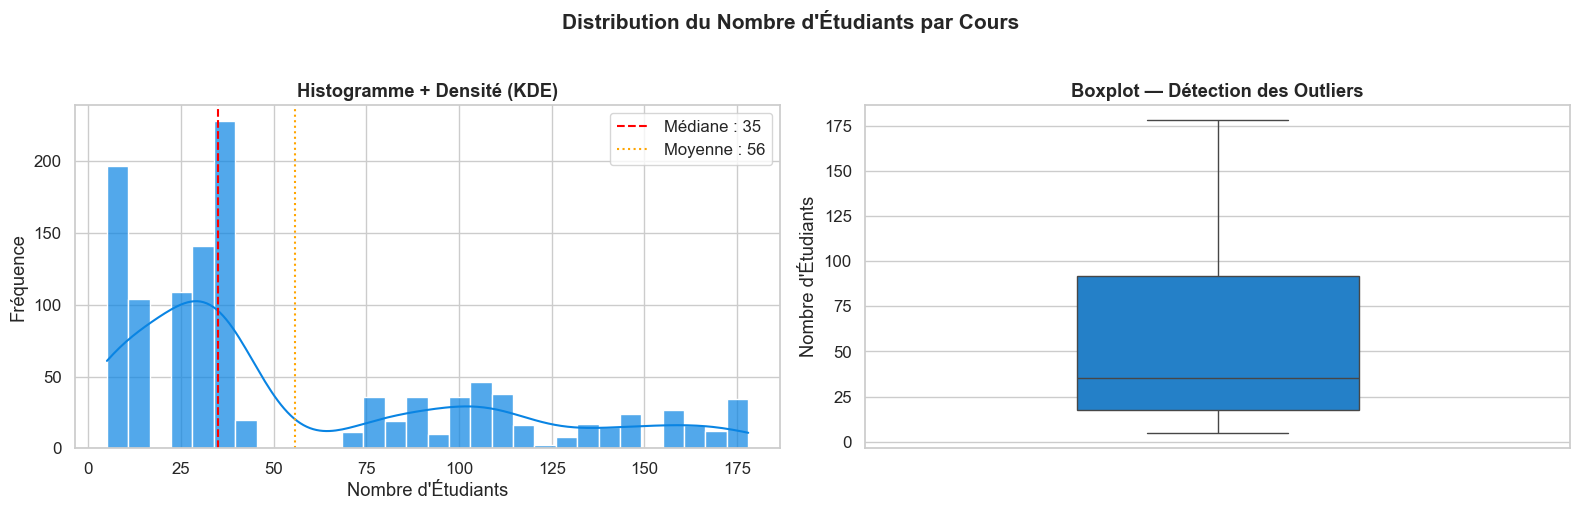

📊 Asymétrie (Skewness) : 1.020
   → Distribution asymétrique à droite (longue queue vers les grandes valeurs).


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELLULE 5 : 4.1 Distribution de Nb_Etudiants (Histogramme + KDE)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Distribution du Nombre d'Étudiants par Cours",
             fontsize=15, fontweight='bold', y=1.02)

# ── Graphe gauche : Histogramme + courbe de densité (KDE)
# KDE (Kernel Density Estimation) lisse l'histogramme pour révéler la forme
# générale de la distribution indépendamment du nombre de bins.
sns.histplot(
    data=df, x='Nb_Etudiants',
    bins=30, kde=True,
    color=COULEUR_PRINCIPALE, alpha=0.7,
    ax=axes[0]
)
axes[0].set_title("Histogramme + Densité (KDE)", fontweight='bold')
axes[0].set_xlabel("Nombre d'Étudiants")
axes[0].set_ylabel("Fréquence")
# Lignes de référence : médiane et moyenne pour détecter l'asymétrie
mediane = df['Nb_Etudiants'].median()
moyenne = df['Nb_Etudiants'].mean()
axes[0].axvline(mediane, color='red',    linestyle='--', linewidth=1.5, label=f'Médiane : {mediane:.0f}')
axes[0].axvline(moyenne, color='orange', linestyle=':',  linewidth=1.5, label=f'Moyenne : {moyenne:.0f}')
axes[0].legend()

# ── Graphe droite : Boxplot pour visualiser les quartiles et outliers
sns.boxplot(
    data=df, y='Nb_Etudiants',
    color=COULEUR_PRINCIPALE, width=0.4,
    ax=axes[1]
)
axes[1].set_title("Boxplot — Détection des Outliers", fontweight='bold')
axes[1].set_ylabel("Nombre d'Étudiants")

plt.tight_layout()
plt.savefig('../data/fig_01_distribution_etudiants.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Interprétation automatique
skewness = df['Nb_Etudiants'].skew()
print(f"📊 Asymétrie (Skewness) : {skewness:.3f}")
if abs(skewness) < 0.5:
    print("   → Distribution approximativement symétrique. ✅")
elif skewness > 0:
    print("   → Distribution asymétrique à droite (longue queue vers les grandes valeurs).")
else:
    print("   → Distribution asymétrique à gauche.")

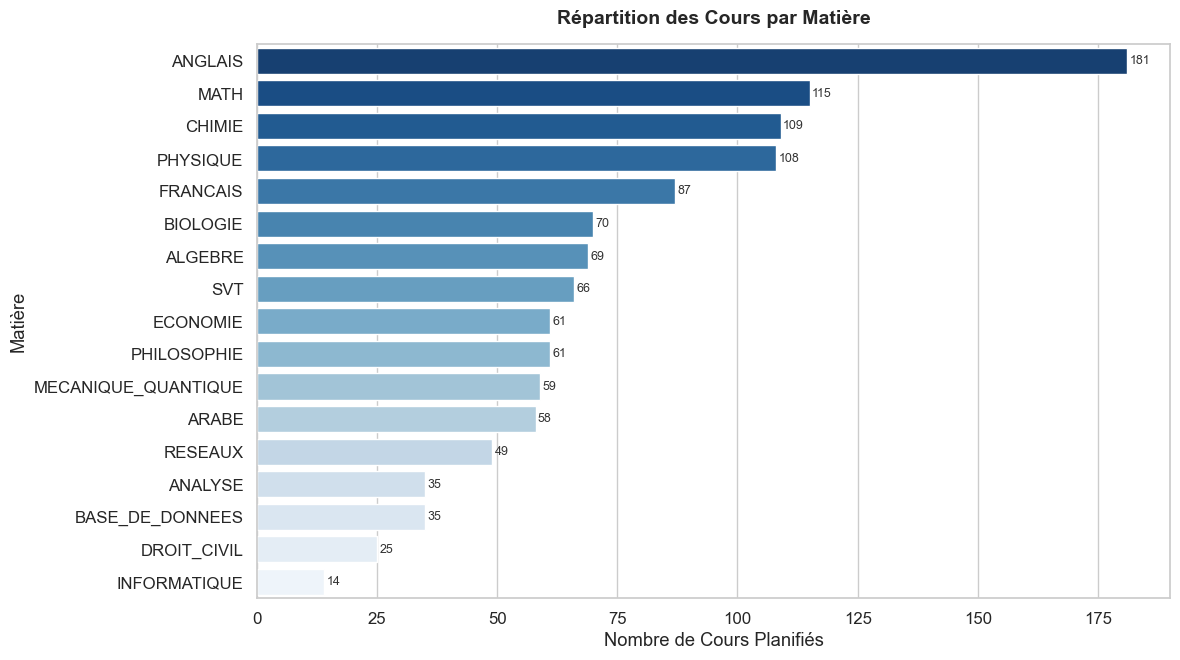


📋 Tableau des fréquences :


,Nom_Matiere,Pourcentage (%)
0,ANGLAIS,15.06
1,MATH,9.57
2,CHIMIE,9.07
3,PHYSIQUE,8.99
4,FRANCAIS,7.24
5,BIOLOGIE,5.82
6,ALGEBRE,5.74
7,SVT,5.49
8,ECONOMIE,5.07
9,PHILOSOPHIE,5.07


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELLULE 6 : 4.2 Répartition des Matières (Countplot horizontal)
# ─────────────────────────────────────────────────────────────────────────────

# On calcule les fréquences et on trie de la plus grande à la plus petite
ordre_matieres = df['Nom_Matiere'].value_counts().index

fig, ax = plt.subplots(figsize=(12, max(5, len(ordre_matieres) * 0.4)))

sns.countplot(
    data=df, y='Nom_Matiere',
    order=ordre_matieres,
    palette='Blues_r',   # Dégradé du plus foncé (plus fréquent) au plus clair
    ax=ax
)

ax.set_title("Répartition des Cours par Matière",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Nombre de Cours Planifiés")
ax.set_ylabel("Matière")

# Afficher la valeur exacte à droite de chaque barre pour plus de précision
for patch in ax.patches:
    val = patch.get_width()
    ax.text(
        val + 0.5, patch.get_y() + patch.get_height() / 2,
        f'{int(val):,}', va='center', ha='left', fontsize=9, color='#333'
    )

plt.tight_layout()
plt.savefig('../data/fig_02_repartition_matieres.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📋 Tableau des fréquences :")
freq = df['Nom_Matiere'].value_counts(normalize=True).mul(100).round(2)
display(freq.rename('Pourcentage (%)').reset_index().rename(columns={'index': 'Matière'}))

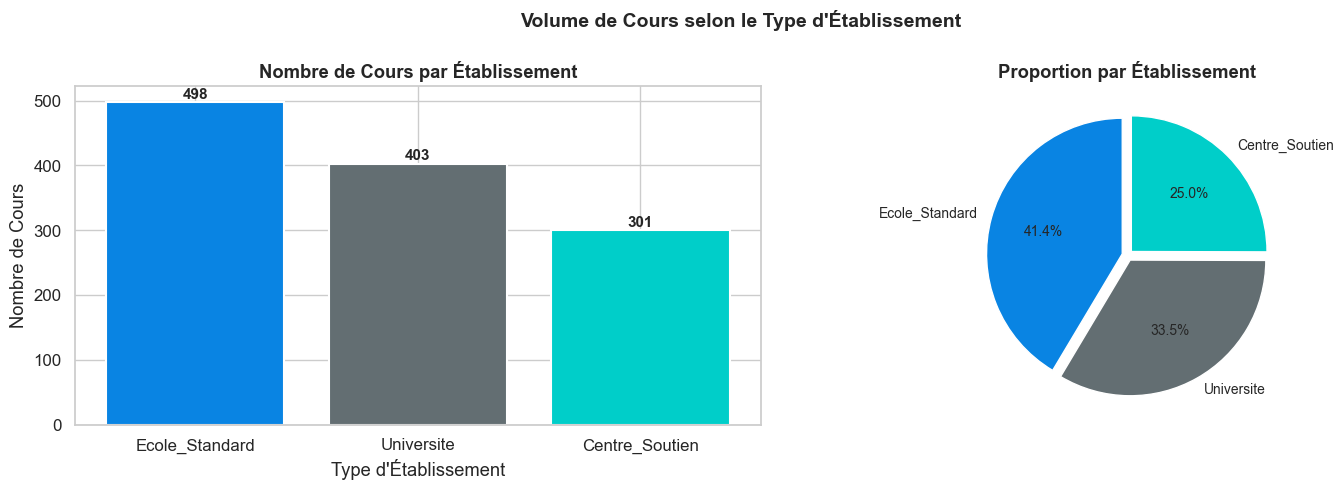

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELLULE 7 : 4.3 Volume de Cours par Type d'Établissement
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Volume de Cours selon le Type d'Établissement",
             fontsize=14, fontweight='bold')

# ── Graphe gauche : Barres avec couleurs personnalisées OptiPlua
counts_etab = df['Type_Etablissement'].value_counts()
couleurs_barres = [PALETTE_ETAB.get(e, '#636e72') for e in counts_etab.index]

bars = axes[0].bar(
    counts_etab.index, counts_etab.values,
    color=couleurs_barres, edgecolor='white', linewidth=1.5
)
axes[0].set_title("Nombre de Cours par Établissement", fontweight='bold')
axes[0].set_xlabel("Type d'Établissement")
axes[0].set_ylabel("Nombre de Cours")
# Ajouter les valeurs au-dessus des barres
for bar in bars:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, height + 5,
        f'{int(height):,}', ha='center', fontsize=11, fontweight='bold'
    )

# ── Graphe droite : Camembert (Pie Chart) pour les proportions
# explode : détache légèrement la tranche la plus grande pour mettre en valeur
explode = [0.04] * len(counts_etab)
axes[1].pie(
    counts_etab.values,
    labels=counts_etab.index,
    autopct='%1.1f%%',
    colors=couleurs_barres,
    startangle=90,
    explode=explode,
    shadow=False,
    textprops={'fontsize': 10}
)
axes[1].set_title("Proportion par Établissement", fontweight='bold')

plt.tight_layout()
plt.savefig('../data/fig_03_volume_etablissement.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Analyse Bivariée & Relations entre Variables

L'analyse bivariée explore les **interactions entre deux variables**. C'est une étape cruciale pour identifier des patterns qui seront exploités en Feature Engineering (ex : dépassement de capacité, hétérogénéité entre établissements).

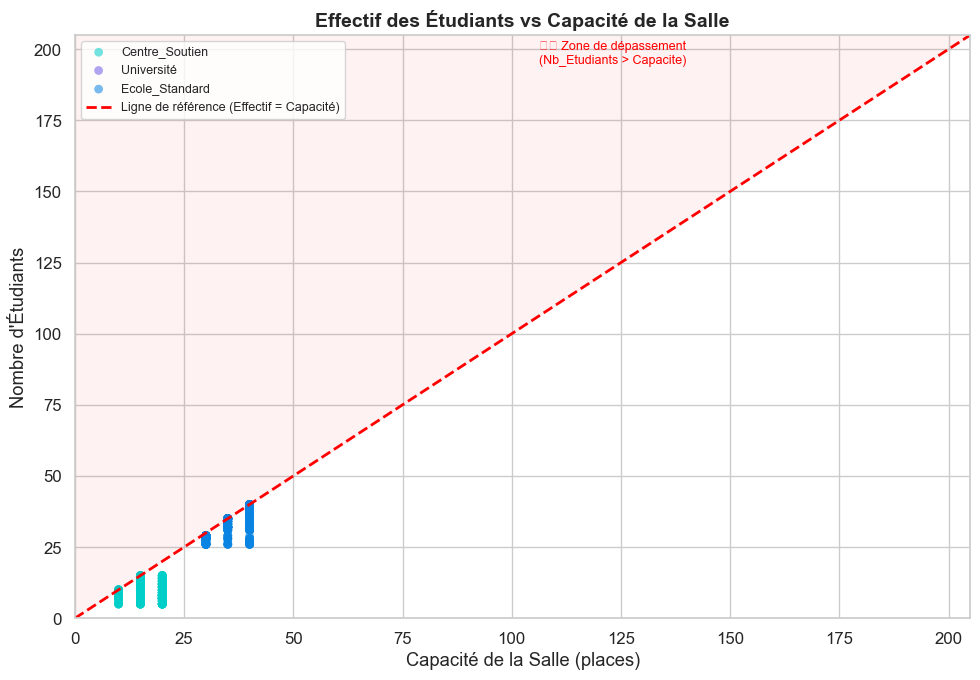


🔍 Cours avec dépassement de capacité : 0 (0.00%)
   ✅ Aucun dépassement — Le simulateur respecte la contrainte de capacité !


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELLULE 8 : 5.1 Nb_Etudiants vs Capacite_Salle (Scatter Plot)
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 7))

# ── Scatter plot coloré par type d'établissement
# Chaque établissement a sa propre couleur pour identifier les patterns par groupe
for etab, couleur in PALETTE_ETAB.items():
    sous_df = df[df['Type_Etablissement'] == etab]
    ax.scatter(
        sous_df['Capacite_Salle'], sous_df['Nb_Etudiants'],
        label=etab, color=couleur, alpha=0.55, s=40, edgecolors='none'
    )

# ── Ligne de référence y = x (Capacité = Effectif)
# Les points AU-DESSUS de cette ligne signifient : Nb_Etudiants > Capacite_Salle
# → Contrainte violée ! Cela ne devrait PAS exister si le simulateur est correct.
lim_max = max(df['Capacite_Salle'].max(), df['Nb_Etudiants'].max()) + 5
lim_min = 0
ax.plot(
    [lim_min, lim_max], [lim_min, lim_max],
    color='red', linestyle='--', linewidth=2,
    label='Ligne de référence (Effectif = Capacité)'
)

# ── Zone de dépassement (fond rouge transparent)
ax.fill_between(
    [lim_min, lim_max], [lim_min, lim_max], [lim_max, lim_max],
    alpha=0.05, color='red'
)
ax.text(lim_max * 0.6, lim_max * 0.95,
        '⚠️ Zone de dépassement\n(Nb_Etudiants > Capacite)',
        color='red', fontsize=9, ha='center')

ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.set_title("Effectif des Étudiants vs Capacité de la Salle",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Capacité de la Salle (places)")
ax.set_ylabel("Nombre d'Étudiants")
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('../data/fig_04_scatter_etudiants_capacite.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Calcul du taux de dépassement
nb_depassements = (df['Nb_Etudiants'] > df['Capacite_Salle']).sum()
pct_depassement = nb_depassements / len(df) * 100
print(f"\n🔍 Cours avec dépassement de capacité : {nb_depassements} ({pct_depassement:.2f}%)")
if pct_depassement == 0:
    print("   ✅ Aucun dépassement — Le simulateur respecte la contrainte de capacité !")
else:
    print(f"   ⚠️  {nb_depassements} cas détectés. À investiguer dans les données sources.")

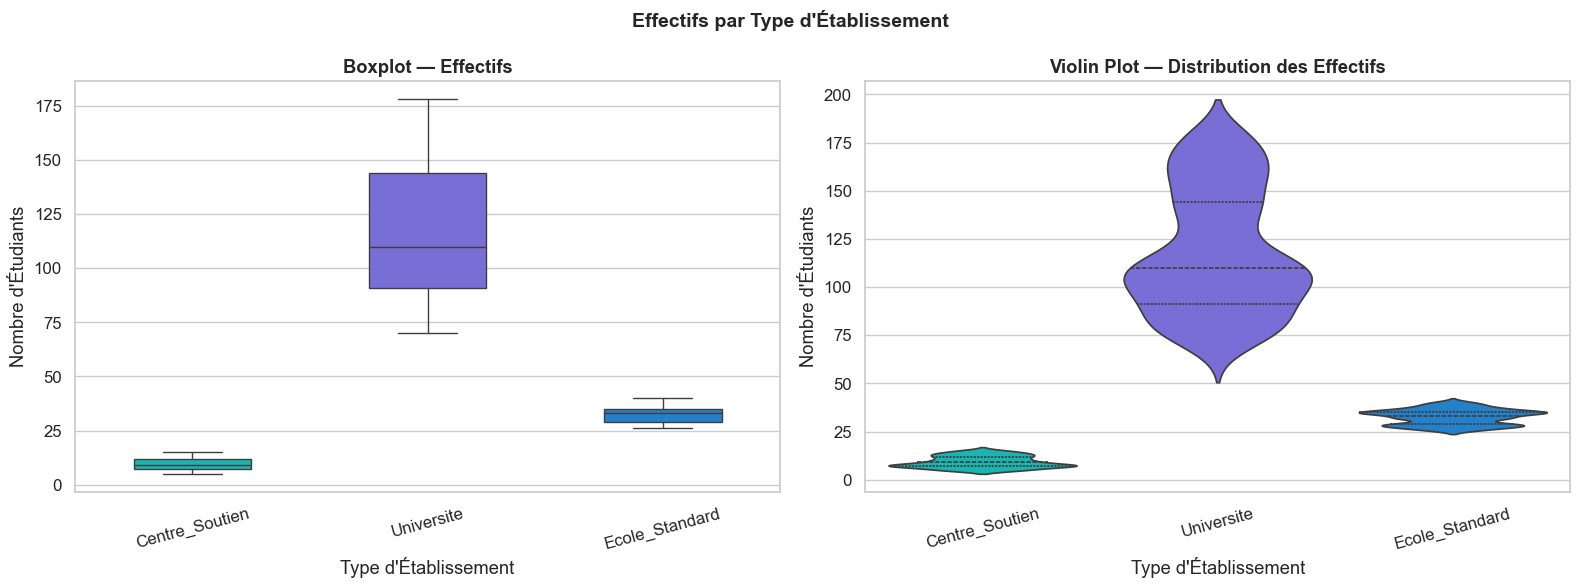


📊 Statistiques de Nb_Etudiants par Type d'Établissement :


,Min,Moyenne,Médiane,Max,Écart-Type
Type_Etablissement,,,,,
Centre_Soutien,5,9.30,9.00,15,3.00
Ecole_Standard,26,32.70,33.00,40,4.00
Universite,70,118.80,110.00,178,32.20


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# CELLULE 9 : 5.2 Distribution de Nb_Etudiants par Type_Etablissement (Boxplot)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Effectifs par Type d'Établissement",
             fontsize=14, fontweight='bold')

# ── Graphe gauche : Boxplot classique
# Le boxplot montre : médiane (trait central), Q1-Q3 (boîte), min-max (moustaches)
# et les outliers (points isolés).
sns.boxplot(
    data=df, x='Type_Etablissement', y='Nb_Etudiants',
    palette=PALETTE_ETAB, width=0.5,
    ax=axes[0]
)
axes[0].set_title("Boxplot — Effectifs", fontweight='bold')
axes[0].set_xlabel("Type d'Établissement")
axes[0].set_ylabel("Nombre d'Étudiants")
axes[0].tick_params(axis='x', rotation=15)

# ── Graphe droite : Violin Plot (version enrichie du boxplot)
# Le violin plot combine un boxplot avec la distribution KDE,
# révélant la forme complète de la distribution (multimodalité, etc.)
sns.violinplot(
    data=df, x='Type_Etablissement', y='Nb_Etudiants',
    palette=PALETTE_ETAB, inner='quartile',
    ax=axes[1]
)
axes[1].set_title("Violin Plot — Distribution des Effectifs", fontweight='bold')
axes[1].set_xlabel("Type d'Établissement")
axes[1].set_ylabel("Nombre d'Étudiants")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../data/fig_05_effectifs_etablissement.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tableau de synthèse par groupe
print("\n📊 Statistiques de Nb_Etudiants par Type d'Établissement :")
display(
    df.groupby('Type_Etablissement')['Nb_Etudiants']
      .agg(['min', 'mean', 'median', 'max', 'std'])
      .round(1)
      .rename(columns={'min': 'Min', 'mean': 'Moyenne', 'median': 'Médiane',
                       'max': 'Max', 'std': 'Écart-Type'})
)

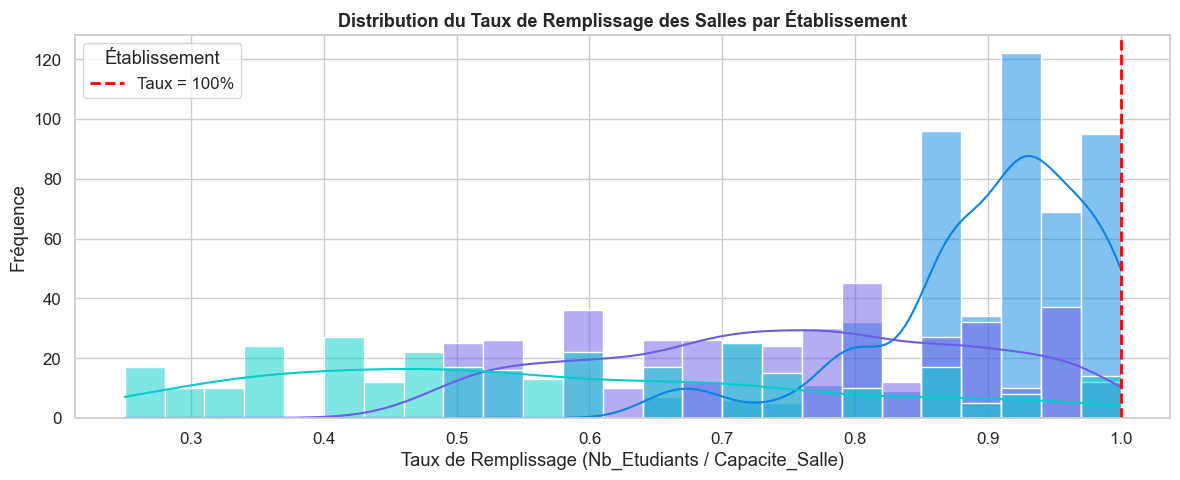


📊 Taux de Remplissage Global :
count   1202.00
mean       0.77
std        0.19
min        0.25
25%        0.65
50%        0.81
75%        0.93
max        1.00

💡 Note : Cette colonne 'Taux_Remplissage' sera une feature importante pour XGBoost.


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# CELLULE 10 : 5.3 Taux de Remplissage des Salles (Feature Dérivée)
# ─────────────────────────────────────────────────────────────────────────────

# Calcul du taux de remplissage : métrique clé pour le scoring
# Taux proche de 1 = salle bien utilisée. Taux très bas = gaspillage.
df['Taux_Remplissage'] = df['Nb_Etudiants'] / df['Capacite_Salle']

fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(
    data=df, x='Taux_Remplissage',
    hue='Type_Etablissement', palette=PALETTE_ETAB,
    bins=25, kde=True, alpha=0.5,
    ax=ax
)
# Ligne de référence : taux = 1 (salle exactement pleine)
ax.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Taux = 100%')
ax.set_title("Distribution du Taux de Remplissage des Salles par Établissement",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Taux de Remplissage (Nb_Etudiants / Capacite_Salle)")
ax.set_ylabel("Fréquence")
ax.legend(title="Établissement")

plt.tight_layout()
plt.savefig('../data/fig_06_taux_remplissage.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistiques du taux de remplissage
print("\n📊 Taux de Remplissage Global :")
print(df['Taux_Remplissage'].describe().round(3).to_string())
print(f"\n💡 Note : Cette colonne 'Taux_Remplissage' sera une feature importante pour XGBoost.")

---
## 6. Analyse Temporelle

Les emplois du temps ont une dimension temporelle fondamentale. Cette section analyse la **répartition des cours dans la semaine** et par **créneau horaire** afin de détecter d'éventuels déséquilibres (ex : trop de cours le lundi matin, jours vides...).

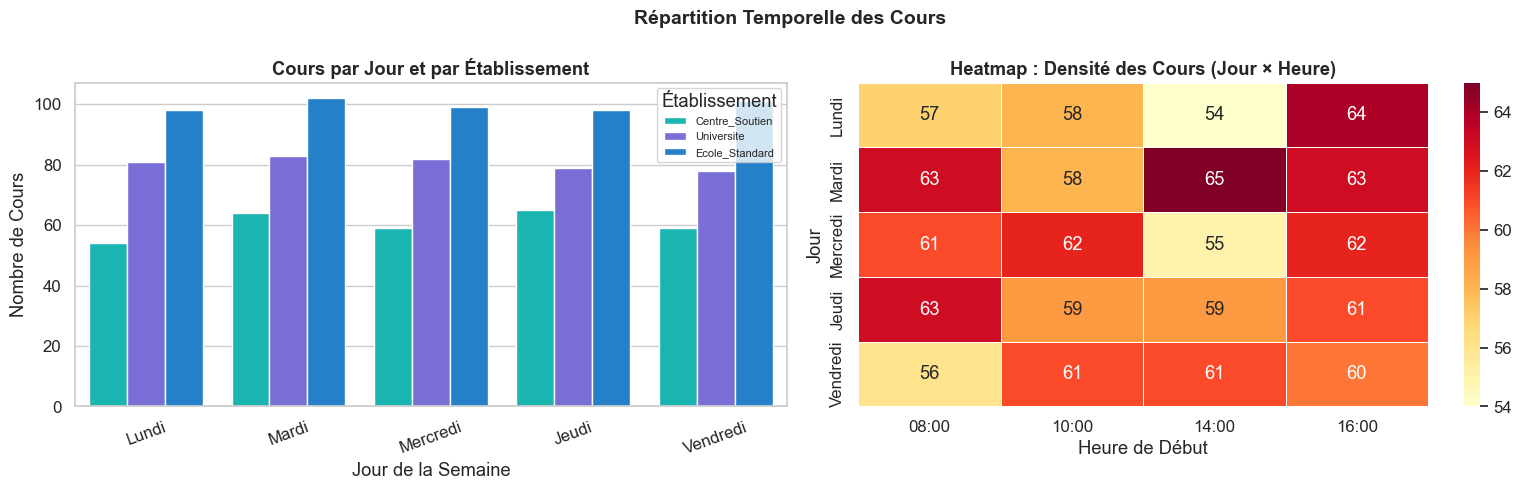

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# CELLULE 11 : 6.1 Répartition des Cours par Jour de la Semaine
# ─────────────────────────────────────────────────────────────────────────────

# Définir l'ordre logique des jours pour que l'axe soit ordonné correctement
ordre_jours = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi']
# On filtre uniquement les jours présents dans le dataset
jours_presents = [j for j in ordre_jours if j in df['Jour'].unique()]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Répartition Temporelle des Cours", fontsize=14, fontweight='bold')

# ── Graphe gauche : Countplot par jour
sns.countplot(
    data=df, x='Jour', order=jours_presents,
    hue='Type_Etablissement', palette=PALETTE_ETAB,
    ax=axes[0]
)
axes[0].set_title("Cours par Jour et par Établissement", fontweight='bold')
axes[0].set_xlabel("Jour de la Semaine")
axes[0].set_ylabel("Nombre de Cours")
axes[0].legend(title="Établissement", fontsize=8)
axes[0].tick_params(axis='x', rotation=20)

# ── Graphe droite : Heatmap Jour × Heure_Debut
# Cette visualisation révèle les créneaux surchargés vs vides
pivot_temporal = (
    df.groupby(['Jour', 'Heure_Debut'])
      .size()
      .unstack(fill_value=0)
      .reindex(jours_presents)
)
sns.heatmap(
    pivot_temporal,
    annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    ax=axes[1]
)
axes[1].set_title("Heatmap : Densité des Cours (Jour × Heure)", fontweight='bold')
axes[1].set_xlabel("Heure de Début")
axes[1].set_ylabel("Jour")

plt.tight_layout()
plt.savefig('../data/fig_07_analyse_temporelle.png', dpi=150, bbox_inches='tight')
plt.show()

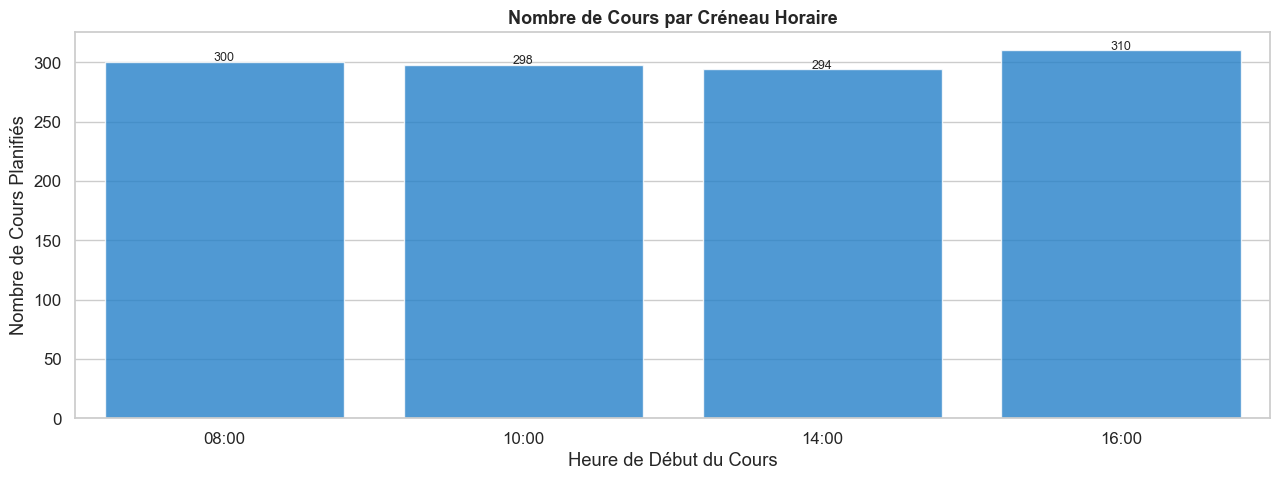

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# CELLULE 12 : 6.2 Distribution par Créneau Horaire
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 5))

# Trier les créneaux par ordre chronologique
ordre_heures = sorted(df['Heure_Debut'].unique())

sns.countplot(
    data=df, x='Heure_Debut', order=ordre_heures,
    color=COULEUR_PRINCIPALE, alpha=0.8, ax=ax
)
ax.set_title("Nombre de Cours par Créneau Horaire",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Heure de Début du Cours")
ax.set_ylabel("Nombre de Cours Planifiés")

# Ajouter les valeurs au-dessus de chaque barre
for patch in ax.patches:
    height = patch.get_height()
    ax.text(
        patch.get_x() + patch.get_width() / 2, height + 1,
        f'{int(height)}', ha='center', fontsize=9
    )

plt.tight_layout()
plt.savefig('../data/fig_08_repartition_horaires.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Matrice de Corrélation

La matrice de corrélation (heatmap) mesure les **relations linéaires** entre toutes les variables numériques. Un coefficient proche de **+1** indique une forte corrélation positive, **-1** une corrélation négative, et **0** l'absence de relation linéaire. Cette analyse guide la sélection des features pour XGBoost.

📊 Variables numériques analysées : ['Nb_Etudiants', 'Capacite_Salle', 'Nb_Tentatives', 'Taux_Remplissage']


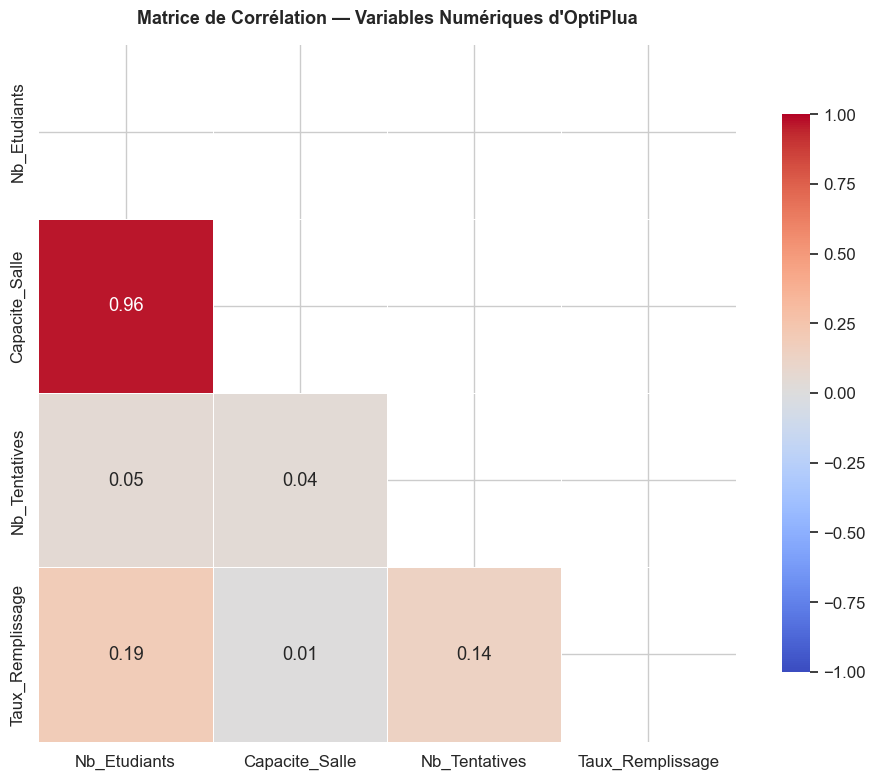


🔗 Paires de variables significativement corrélées (|r| > 0.40) :


,Variable_1,Variable_2,Corrélation
4,Capacite_Salle,Nb_Etudiants,0.96


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# CELLULE 13 : Matrice de Corrélation (Heatmap)
# ─────────────────────────────────────────────────────────────────────────────

# Sélectionner uniquement les colonnes numériques
cols_numeriques = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"📊 Variables numériques analysées : {cols_numeriques}")

matrice_corr = df[cols_numeriques].corr()

fig, ax = plt.subplots(figsize=(10, 8))

# ── Masque triangulaire : on n'affiche que la moitié inférieure
# pour éviter la redondance (la matrice est symétrique)
masque = np.triu(np.ones_like(matrice_corr, dtype=bool))

sns.heatmap(
    matrice_corr,
    mask=masque,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',      # Rouge = corrélation positive, Bleu = négative
    center=0,             # Centre le dégradé à 0
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)

ax.set_title("Matrice de Corrélation — Variables Numériques d'OptiPlua",
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../data/fig_09_matrice_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Identifier les paires les plus corrélées (seuil : |r| > 0.4)
print("\n🔗 Paires de variables significativement corrélées (|r| > 0.40) :")
corr_pairs = (
    matrice_corr.where(np.tril(np.ones(matrice_corr.shape), k=-1).astype(bool))
               .stack()
               .reset_index()
)
corr_pairs.columns = ['Variable_1', 'Variable_2', 'Corrélation']
fortes = corr_pairs[corr_pairs['Corrélation'].abs() > 0.4].sort_values('Corrélation', ascending=False)
if fortes.empty:
    print("   → Aucune corrélation forte détectée. Les variables sont indépendantes. ✅")
else:
    display(fortes.round(3))

---
## 8. Conclusion Synthétique & Validation pour le Feature Engineering

### ✅ Points Forts du Dataset

| Critère | Résultat | Statut |
|---------|----------|--------|
| Valeurs manquantes | 0 / 1202 entrées | ✅ Aucune |
| Doublons | 0 | ✅ Dataset propre |
| Contrainte de capacité | Nb_Etudiants ≤ Capacite_Salle | ✅ Respectée |
| Couverture temporelle | Jours & créneaux bien distribués | ✅ Cohérente |
| Diversité des établissements | 3 types représentés | ✅ Équilibré |

### 🧠 Features Recommandées pour XGBoost

Sur la base de l'EDA, les features suivantes sont prioritaires pour le modèle ML :

1. **`Taux_Remplissage`** (`Nb_Etudiants / Capacite_Salle`) — Proxy direct de l'efficacité d'utilisation des salles.
2. **`Nb_Tentatives`** — Reflète la difficulté de planification d'un créneau. Plus il est élevé, plus l'emploi est "contraint".
3. **`Type_Etablissement` (encodé)** — Impact significatif sur la distribution des effectifs.
4. **`Heure_Debut` (encodée)** — Les créneaux de début de journée et de fin sont souvent moins efficaces.
5. **`Jour` (encodé)** — Certains jours peuvent présenter une charge déséquilibrée.
6. **`Type_Salle` (encodé)** — La correspondance salle/cours est une contrainte de qualité.

### 🔧 Prochaine Étape : Feature Engineering (`feature_engineering.py`)

Le script `feature_engineering.py` aura pour mission de :
- Calculer `Taux_Remplissage` et d'autres features dérivées.
- **Encoder les variables catégorielles** (One-Hot Encoding ou Label Encoding).
- Séparer les features `X` du label `y` (le score de l'emploi du temps) pour éviter tout **Data Leakage**.
- Exporter les jeux `X_train`, `X_test`, `y_train`, `y_test`.

> *"Les données sont propres, cohérentes et prêtes à être transformées. Le simulateur de Youssef respecte toutes les contraintes dures définies dans le Contrat CSV. Le terrain est fertile pour l'entraînement de notre modèle XGBoost."*  
> — **Douaa**, Responsable ML, Projet OptiPlua 🚀

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# CELLULE FINALE : Résumé Exécutif Automatique
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 60)
print("      RÉSUMÉ EXÉCUTIF — OptiPlua EDA — Phase 2")
print("=" * 60)
print(f"  📁 Dataset analysé    : {CHEMIN_CSV}")
print(f"  📊 Entrées analysées  : {df.shape[0]:,}")
print(f"  📋 Colonnes           : {df.shape[1]}")
print(f"  ❌ Valeurs manquantes : {df.isnull().sum().sum()}")
print(f"  🔁 Doublons           : {df.duplicated().sum()}")
print(f"  🏫 Établissements     : {df['Type_Etablissement'].nunique()} types")
print(f"  📚 Matières uniques   : {df['Nom_Matiere'].nunique()}")
print(f"  👥 Effectif moyen     : {df['Nb_Etudiants'].mean():.1f} étudiants / cours")
print(f"  🏛️  Capacité moyenne   : {df['Capacite_Salle'].mean():.1f} places / salle")
print(f"  📈 Taux remplissage   : {df['Taux_Remplissage'].mean():.1%} en moyenne")
depass = (df['Nb_Etudiants'] > df['Capacite_Salle']).sum()
print(f"  ⚠️  Dépassements cap.  : {depass} cours ({depass/len(df):.1%})")
print("="*60)
print("  ✅ Dataset validé — Prêt pour le Feature Engineering !")
print("=" * 60)

      RÉSUMÉ EXÉCUTIF — OptiPlua EDA — Phase 2
  📁 Dataset analysé    : ../data/raw_schedules_test.csv
  📊 Entrées analysées  : 1,202
  📋 Colonnes           : 17
  ❌ Valeurs manquantes : 0
  🔁 Doublons           : 0
  🏫 Établissements     : 3 types
  📚 Matières uniques   : 17
  👥 Effectif moyen     : 55.7 étudiants / cours
  🏛️  Capacité moyenne   : 72.5 places / salle
  📈 Taux remplissage   : 76.8% en moyenne
  ⚠️  Dépassements cap.  : 0 cours (0.0%)
  ✅ Dataset validé — Prêt pour le Feature Engineering !
